In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [21]:
# Parâmetros do projeto (definidos manualmente)
UF = "PR"
ANO = 2023
MES = 1
CAMINHO_RAW = Path(f"../data/raw/sih_{UF}_{ANO}_{MES:02d}.parquet")
CAMINHO_PROCESSED = Path(f"../data/processed/sih_clean_{UF}_{ANO}_{MES:02d}.parquet")

In [22]:
# Configurações de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## CARREGAMENTO 

In [23]:
df = pd.read_parquet(f'../data/raw/sih_{UF}_{ANO}_{MES:02d}.parquet')

#Visualizar Dataset
print (f"Dados carregados")
print (f"Registros:{len(df)} linhas")
print(f"Colunas {df.shape[1]}")

Dados carregados
Registros:1022423 linhas
Colunas 36


## ESTRUTURA 

In [24]:
df.head()

,SP_GESTOR,SP_UF,SP_AA,SP_MM,SP_CNES,SP_NAIH,SP_PROCREA,SP_DTINTER,SP_DTSAIDA,SP_NUM_PR,...,SP_PF_DOC,SP_PJ_DOC,IN_TP_VAL,SEQUENCIA,REMESSA,SERV_CLA,SP_CIDPRI,SP_CIDSEC,SP_QT_PROC,SP_U_AIH
0,410000,41,2023,01,2729385,4123106805576,0301060088,20230126,20230127,,...,000000000000000,00000002729687,1,33367,HE41000001N202301.DTS,000000,I64,0000,1,0
1,410000,41,2023,01,2729385,4123106805576,0301060088,20230126,20230127,,...,000000000000000,00000002729687,1,33367,HE41000001N202301.DTS,000000,I64,0000,1,0
2,410000,41,2023,01,2729385,4123106805598,0303070129,20230128,20230130,,...,702007890355581,00000000000000,2,33368,HE41000001N202301.DTS,000000,K838,0000,0,1
3,410000,41,2023,01,2729385,4123106805598,0303070129,20230128,20230130,,...,000000000000000,00000002729385,1,33368,HE41000001N202301.DTS,000000,K838,0000,2,0
4,410000,41,2023,01,2729385,4123106805598,0303070129,20230128,20230130,,...,707802687727711,00000002781859,1,33368,HE41000001N202301.DTS,128004,K838,0000,2,0


In [25]:
print(f"Lista das colunas:{df.columns.tolist()}")

Lista das colunas:['SP_GESTOR', 'SP_UF', 'SP_AA', 'SP_MM', 'SP_CNES', 'SP_NAIH', 'SP_PROCREA', 'SP_DTINTER', 'SP_DTSAIDA', 'SP_NUM_PR', 'SP_TIPO', 'SP_CPFCGC', 'SP_ATOPROF', 'SP_TP_ATO', 'SP_QTD_ATO', 'SP_PTSP', 'SP_NF', 'SP_VALATO', 'SP_M_HOSP', 'SP_M_PAC', 'SP_DES_HOS', 'SP_DES_PAC', 'SP_COMPLEX', 'SP_FINANC', 'SP_CO_FAEC', 'SP_PF_CBO', 'SP_PF_DOC', 'SP_PJ_DOC', 'IN_TP_VAL', 'SEQUENCIA', 'REMESSA', 'SERV_CLA', 'SP_CIDPRI', 'SP_CIDSEC', 'SP_QT_PROC', 'SP_U_AIH']


In [26]:
print(f"Tipos: {df.dtypes}")

Tipos: SP_GESTOR     object
SP_UF         object
SP_AA         object
SP_MM         object
SP_CNES       object
SP_NAIH       object
SP_PROCREA    object
SP_DTINTER    object
SP_DTSAIDA    object
SP_NUM_PR     object
SP_TIPO       object
SP_CPFCGC     object
SP_ATOPROF    object
SP_TP_ATO     object
SP_QTD_ATO    object
SP_PTSP       object
SP_NF         object
SP_VALATO     object
SP_M_HOSP     object
SP_M_PAC      object
SP_DES_HOS    object
SP_DES_PAC    object
SP_COMPLEX    object
SP_FINANC     object
SP_CO_FAEC    object
SP_PF_CBO     object
SP_PF_DOC     object
SP_PJ_DOC     object
IN_TP_VAL     object
SEQUENCIA     object
REMESSA       object
SERV_CLA      object
SP_CIDPRI     object
SP_CIDSEC     object
SP_QT_PROC    object
SP_U_AIH      object
dtype: object


In [27]:
print(f"Valores Unicos por Coluna:")
print(df.nunique())

Valores Unicos por Coluna:


SP_GESTOR        31
SP_UF             1
SP_AA             1
SP_MM             1
SP_CNES         284
SP_NAIH       74681
SP_PROCREA     1115
SP_DTINTER      227
SP_DTSAIDA      177
SP_NUM_PR         1
SP_TIPO           1
SP_CPFCGC       360
SP_ATOPROF     2198
SP_TP_ATO         1
SP_QTD_ATO      161
SP_PTSP         176
SP_NF          7913
SP_VALATO     20274
SP_M_HOSP       194
SP_M_PAC        657
SP_DES_HOS        2
SP_DES_PAC        2
SP_COMPLEX        2
SP_FINANC         4
SP_CO_FAEC       12
SP_PF_CBO        77
SP_PF_DOC      7176
SP_PJ_DOC       835
IN_TP_VAL         2
SEQUENCIA     40921
REMESSA          31
SERV_CLA         90
SP_CIDPRI      3588
SP_CIDSEC         1
SP_QT_PROC      161
SP_U_AIH          2
dtype: int64


In [28]:
#resumo da estrutura
df.describe(include='all')

,SP_GESTOR,SP_UF,SP_AA,SP_MM,SP_CNES,SP_NAIH,SP_PROCREA,SP_DTINTER,SP_DTSAIDA,SP_NUM_PR,...,SP_PF_DOC,SP_PJ_DOC,IN_TP_VAL,SEQUENCIA,REMESSA,SERV_CLA,SP_CIDPRI,SP_CIDSEC,SP_QT_PROC,SP_U_AIH
count,1022423,1022423,1022423,1022423,1022423,1022423,1022423,1022423,1022423,1022423,...,1022423,1022423,1022423,1022423,1022423,1022423,1022423,1022423,1022423,1022423
unique,31,1,1,1,284,74681,1115,227,177,1,...,7176,835,2,40921,31,90,3588,1,161,2
top,410000,41,2023,01,0015245,4122112375084,0303010037,20230109,20230105,,...,000000000000000,00000000000000,1,8,HE41000001N202301.DTS,000000,O800,0000,1,0
freq,480262,1022423,1022423,1022423,65273,252,56027,20123,23807,1022423,...,714348,206623,816660,415,480262,870485,30795,1022423,562448,947680


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1022423 entries, 0 to 1022422
Data columns (total 36 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   SP_GESTOR   1022423 non-null  object
 1   SP_UF       1022423 non-null  object
 2   SP_AA       1022423 non-null  object
 3   SP_MM       1022423 non-null  object
 4   SP_CNES     1022423 non-null  object
 5   SP_NAIH     1022423 non-null  object
 6   SP_PROCREA  1022423 non-null  object
 7   SP_DTINTER  1022423 non-null  object
 8   SP_DTSAIDA  1022423 non-null  object
 9   SP_NUM_PR   1022423 non-null  object
 10  SP_TIPO     1022423 non-null  object
 11  SP_CPFCGC   1022423 non-null  object
 12  SP_ATOPROF  1022423 non-null  object
 13  SP_TP_ATO   1022423 non-null  object
 14  SP_QTD_ATO  1022423 non-null  object
 15  SP_PTSP     1022423 non-null  object
 16  SP_NF       1022423 non-null  object
 17  SP_VALATO   1022423 non-null  object
 18  SP_M_HOSP   1022423 non-null  object
 19  

## QUALIDADE DOS DADOS

In [30]:
#Valores nulos
#somente uma confirmação pois ja vimos vendo a estrutura que nao temos valores nulos
nulos = df.isnull().sum()
nulos_percent = (nulos / len(df))*100

df_nulos = pd.DataFrame({
    'Nulos' : nulos,
    'Percentual' : nulos_percent

}).sort_values('Nulos', ascending=False)
print(f"Valores Nulos por coluna:")
df_nulos

Valores Nulos por coluna:


,Nulos,Percentual
SP_GESTOR,0,0.0
SP_UF,0,0.0
SP_AA,0,0.0
SP_MM,0,0.0
SP_CNES,0,0.0
SP_NAIH,0,0.0
SP_PROCREA,0,0.0
SP_DTINTER,0,0.0
SP_DTSAIDA,0,0.0
SP_NUM_PR,0,0.0


In [31]:
#Analisando Duplicadas

# 1. Estatísticas gerais
duplicatas_exatas = df.duplicated().sum()
pct_duplicatas = (duplicatas_exatas / len(df)) * 100

print(f"Registros totais: {len(df):,}")
print(f"Duplicatas exatas (cópias): {duplicatas_exatas:,} ({pct_duplicatas:.2f}%)")


Registros totais: 1,022,423
Duplicatas exatas (cópias): 72,929 (7.13%)


In [32]:
# Registros envolvidos (inclui primeira ocorrência)
if duplicatas_exatas > 0:
    registros_envolvidos = df.duplicated(keep=False).sum()
    print(f"Registros envolvidos em duplicatas: {registros_envolvidos:,} ({registros_envolvidos/len(df)*100:.2f}%)")

Registros envolvidos em duplicatas: 103,633 (10.14%)


In [33]:
# 2. Verificar se TODAS as AIHs com duplicatas têm o mesmo paciente
df_dup = df[df.duplicated(keep=False)]  # todos os registros envolvidos

if len(df_dup) > 0:
    # Agrupa por AIH e conta quantos pacientes únicos existem em cada uma
    aihs_com_duplicatas = df_dup.groupby('SP_NAIH')['SP_CPFCGC'].nunique()
    
    # Quantas AIHs têm mais de um paciente?
    aihs_com_pacientes_diferentes = (aihs_com_duplicatas > 1).sum()
    
    print(f"AIHs com múltiplos registros: {len(aihs_com_duplicatas)}")
    print(f"AIHs com pacientes diferentes: {aihs_com_pacientes_diferentes}")
    
    if aihs_com_pacientes_diferentes == 0:
        print("TODAS as AIHs têm o MESMO paciente - seguro remover duplicatas exatas")
    else:
        print(f"{aihs_com_pacientes_diferentes} AIHs têm pacientes diferentes")

AIHs com múltiplos registros: 9323
AIHs com pacientes diferentes: 1
1 AIHs têm pacientes diferentes


In [34]:
#Remover duplicatas exatas
antes = len(df)
df = df.drop_duplicates()
depois = len(df)
print(f"\nRemovidas: {antes - depois:,} registros")


Removidas: 72,929 registros


## COLUNAS


In [35]:
colunas_essenciais = [
       'SP_GESTOR',   # Código do Município
    'SP_CNES',     # ID do Hospital
    'SP_CIDPRI',   # Código CID-10 da doença
    'SP_DTINTER',  # Data de Internação
    'SP_DTSAIDA',  # Data de Saída
    'SP_VALATO',   # Valor do Ato Profissional
    'SP_M_PAC',    # Município do Paciente
    'SP_AA',       # Ano
    'SP_MM'        # Mês
]

df_filtrado = df[colunas_essenciais].copy()
df_filtrado

,SP_GESTOR,SP_CNES,SP_CIDPRI,SP_DTINTER,SP_DTSAIDA,SP_VALATO,SP_M_PAC,SP_AA,SP_MM
0,410000,2729385,I64,20230126,20230127,0.00,411270,2023,01
1,410000,2729385,I64,20230126,20230127,0.00,411270,2023,01
2,410000,2729385,K838,20230128,20230130,41.95,410980,2023,01
3,410000,2729385,K838,20230128,20230130,16.00,410980,2023,01
4,410000,2729385,K838,20230128,20230130,16.78,410980,2023,01
...,...,...,...,...,...,...,...,...,...
1022418,410000,2742039,T012,20230113,20230114,33.34,411930,2023,01
1022419,410000,2742039,I64,20230105,20230105,33.34,411930,2023,01
1022420,410000,2742039,T012,20230110,20230110,33.34,411930,2023,01
1022421,410000,2742039,T012,20230103,20230104,33.34,411930,2023,01


As colunas selecionadas são essenciais para responder às perguntas de negócio:

1. **SP_GESTOR**: Permite análise por município gestor (quem financiou o atendimento)
2. **SP_CNES**: Permite integração com dados de leitos (CNES) e análise por hospital
3. **SP_CIDPRI**: Permite análise das principais causas de internação
4. **SP_DTINTER/SP_DTSAIDA**: Permite calcular tempo de permanência e análises temporais
5. **SP_VALATO**: Permite análise de custos e eficiência
6. **SP_M_PAC**: Permite calcular deslocamento de pacientes (demanda regional)
7. **SP_AA/SP_MM**: Permite filtrar por período e análises sazonais

As colunas removidas são operacionais ou administrativas, não necessárias para os KPIs do dashboard.

In [36]:
#Mudar o tipo das colunas
df_filtrado['SP_DTINTER'] = pd.to_datetime(df_filtrado['SP_DTINTER'], format='%Y%m%d', errors='coerce')
df_filtrado['SP_DTSAIDA'] = pd.to_datetime(df_filtrado['SP_DTSAIDA'], format='%Y%m%d', errors ='coerce')

df_filtrado['SP_VALATO'] = pd.to_numeric(df_filtrado['SP_VALATO'], errors = 'coerce' )

df_filtrado['SP_AA'] = pd.to_numeric(df_filtrado['SP_AA'], errors='coerce').fillna(0).astype(int)
df_filtrado['SP_MM'] = pd.to_numeric(df_filtrado['SP_MM'], errors='coerce').fillna(0).astype(int)

df_filtrado.dtypes

,0
SP_GESTOR,object
SP_CNES,object
SP_CIDPRI,object
SP_DTINTER,datetime64[ns]
SP_DTSAIDA,datetime64[ns]
SP_VALATO,float64
SP_M_PAC,object
SP_AA,int64
SP_MM,int64


In [37]:
#Mudar o noem das colunas
dicionario_colunas = {
    'SP_CNES': 'id_hospital',
    'SP_GESTOR': 'codigo_municipio',
    'SP_CIDPRI': 'codigo_diagnostico',
    'SP_DTINTER': 'data_internacao',
    'SP_DTSAIDA': 'data_saida',
    'SP_VALATO': 'valor_procedimento',
    'SP_M_PAC': 'codigo_municipio_paciente',
    'SP_AA': 'ano_competencia',
    'SP_MM': 'mes_competencia'
}

df_filtrado.rename(columns=dicionario_colunas, inplace=True)
df_filtrado

,codigo_municipio,id_hospital,codigo_diagnostico,data_internacao,data_saida,valor_procedimento,codigo_municipio_paciente,ano_competencia,mes_competencia
0,410000,2729385,I64,2023-01-26,2023-01-27,0.00,411270,2023,1
1,410000,2729385,I64,2023-01-26,2023-01-27,0.00,411270,2023,1
2,410000,2729385,K838,2023-01-28,2023-01-30,41.95,410980,2023,1
3,410000,2729385,K838,2023-01-28,2023-01-30,16.00,410980,2023,1
4,410000,2729385,K838,2023-01-28,2023-01-30,16.78,410980,2023,1
...,...,...,...,...,...,...,...,...,...
1022418,410000,2742039,T012,2023-01-13,2023-01-14,33.34,411930,2023,1
1022419,410000,2742039,I64,2023-01-05,2023-01-05,33.34,411930,2023,1
1022420,410000,2742039,T012,2023-01-10,2023-01-10,33.34,411930,2023,1
1022421,410000,2742039,T012,2023-01-03,2023-01-04,33.34,411930,2023,1


In [39]:
# 1. CNES - garantir 7 dígitos com zfill
#    Primeiro converte para string, depois preenche com zeros à esquerda
df_filtrado['id_hospital'] = df_filtrado['id_hospital'].astype(str).str.zfill(7)
print(f"CNES padronizado (7 dígitos)")

# 2. Municípios - garantir 6 dígitos com zfill
df_filtrado['codigo_municipio'] = df_filtrado['codigo_municipio'].astype(str).str.zfill(6)
df_filtrado['codigo_municipio_paciente'] = df_filtrado['codigo_municipio_paciente'].astype(str).str.zfill(6)

CNES padronizado (7 dígitos)


# FEATURE ENGINEERING

In [40]:
#Coluna do tempo de internação
df_filtrado['dias_internacao'] = (df_filtrado['data_saida'] - df_filtrado['data_internacao']).dt.days
df_filtrado.head(2)

,codigo_municipio,id_hospital,codigo_diagnostico,data_internacao,data_saida,valor_procedimento,codigo_municipio_paciente,ano_competencia,mes_competencia,dias_internacao
0,410000,2729385,I64,2023-01-26,2023-01-27,0.0,411270,2023,1,1
1,410000,2729385,I64,2023-01-26,2023-01-27,0.0,411270,2023,1,1


In [41]:
#Coluna que diz se houve deslocamneto significativo pelo paciente
df_filtrado['paciente_viajou'] = df_filtrado['codigo_municipio_paciente'] != df_filtrado['codigo_municipio']
df_filtrado.head(2)

,codigo_municipio,id_hospital,codigo_diagnostico,data_internacao,data_saida,valor_procedimento,codigo_municipio_paciente,ano_competencia,mes_competencia,dias_internacao,paciente_viajou
0,410000,2729385,I64,2023-01-26,2023-01-27,0.0,411270,2023,1,1,True
1,410000,2729385,I64,2023-01-26,2023-01-27,0.0,411270,2023,1,1,True


In [42]:
#Coluna para dia da semana
df_filtrado['dia_semana'] = (df_filtrado['data_internacao']).dt.day_name()
df_filtrado.head()

,codigo_municipio,id_hospital,codigo_diagnostico,data_internacao,data_saida,valor_procedimento,codigo_municipio_paciente,ano_competencia,mes_competencia,dias_internacao,paciente_viajou,dia_semana
0,410000,2729385,I64,2023-01-26,2023-01-27,0.00,411270,2023,1,1,True,Thursday
1,410000,2729385,I64,2023-01-26,2023-01-27,0.00,411270,2023,1,1,True,Thursday
2,410000,2729385,K838,2023-01-28,2023-01-30,41.95,410980,2023,1,2,True,Saturday
3,410000,2729385,K838,2023-01-28,2023-01-30,16.00,410980,2023,1,2,True,Saturday
4,410000,2729385,K838,2023-01-28,2023-01-30,16.78,410980,2023,1,2,True,Saturday


In [43]:
#Coluna de junção mes e ano
df_filtrado['mes_ano'] = df_filtrado['data_internacao'].dt.to_period('M')
df_filtrado.head(2)

,codigo_municipio,id_hospital,codigo_diagnostico,data_internacao,data_saida,valor_procedimento,codigo_municipio_paciente,ano_competencia,mes_competencia,dias_internacao,paciente_viajou,dia_semana,mes_ano
0,410000,2729385,I64,2023-01-26,2023-01-27,0.0,411270,2023,1,1,True,Thursday,2023-01
1,410000,2729385,I64,2023-01-26,2023-01-27,0.0,411270,2023,1,1,True,Thursday,2023-01


In [44]:
#Coluna para classificar os dias
df_filtrado['tipo_dia'] = df_filtrado['dia_semana'].apply(lambda x: 'Fim de Semana' if x in ['Saturday', 'Sunday'] else 'Dia Útil')
df_filtrado.head(2)

,codigo_municipio,id_hospital,codigo_diagnostico,data_internacao,data_saida,valor_procedimento,codigo_municipio_paciente,ano_competencia,mes_competencia,dias_internacao,paciente_viajou,dia_semana,mes_ano,tipo_dia
0,410000,2729385,I64,2023-01-26,2023-01-27,0.0,411270,2023,1,1,True,Thursday,2023-01,Dia Útil
1,410000,2729385,I64,2023-01-26,2023-01-27,0.0,411270,2023,1,1,True,Thursday,2023-01,Dia Útil


# ANÁLISE EXPLORATÓRIA


In [45]:
#Analise de deslocamento
total_internacoes = len(df_filtrado)
total_viajaram = df_filtrado['paciente_viajou'].sum()
total_nao_viajaram = total_internacoes - total_viajaram
porcentagem_deslocamento = (total_viajaram / total_internacoes) * 100

print(" --- RELATÓRIO DE PRESSÃO REGIONAL ---")
print(f"• Total de atendimentos analisados: {total_internacoes}")
print(f"• Pacientes atendidos fora de sua cidade natal: {total_viajaram}")
print(f"• Taxa de evasão municipal (pacientes que viajaram): {porcentagem_deslocamento:.2f}%")
print("-----------------------------------------\n")

 --- RELATÓRIO DE PRESSÃO REGIONAL ---
• Total de atendimentos analisados: 949494
• Pacientes atendidos fora de sua cidade natal: 643541
• Taxa de evasão municipal (pacientes que viajaram): 67.78%
-----------------------------------------



In [46]:
descricao_cid = {
    'O800': 'Parto normal',
    'I64': 'AVC (Derrame)',
    'O820': 'Cesariana',
    'J189': 'Pneumonia',
    'I200': 'Angina',
    'A419': 'Septicemia',
    'I219': 'Infarto',
    'I500': 'Insuficiência cardíaca',
    'A499': 'Infecção bacteriana',
    'N390': 'Infecção urinária'
}


In [47]:
top_diagnosticos = df_filtrado['codigo_diagnostico'].value_counts().head(10)

print("   CID | Quantidade | Descrição")
print("   " + "-"*45)
for i, (cid, qtd) in enumerate(top_diagnosticos.items(), 1):
    desc = descricao_cid.get(cid, cid)
    print(f"   {i:2d}. {cid} | {qtd:6,} | {desc}")

   CID | Quantidade | Descrição
   ---------------------------------------------
    1. O800 | 29,580 | Parto normal
    2. I64 | 24,509 | AVC (Derrame)
    3. O820 | 24,452 | Cesariana
    4. J189 | 19,395 | Pneumonia
    5. I200 | 19,239 | Angina
    6. I219 | 17,560 | Infarto
    7. A419 | 16,722 | Septicemia
    8. I500 | 15,988 | Insuficiência cardíaca
    9. N390 | 12,318 | Infecção urinária
   10. A499 | 11,486 | Infecção bacteriana


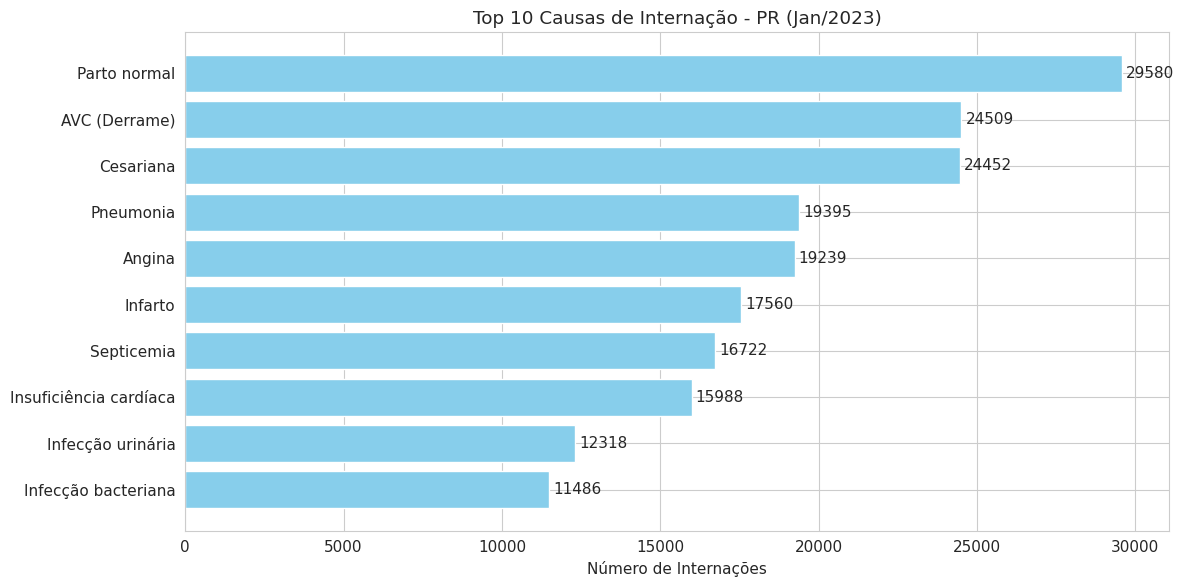

In [48]:
plt.figure(figsize=(12, 6))
bars = plt.barh(
    [descricao_cid.get(cid, cid) for cid in top_diagnosticos.index],
    top_diagnosticos.values,
    color='skyblue'
)
plt.bar_label(bars, padding=3)
plt.xlabel('Número de Internações')
plt.title('Top 10 Causas de Internação - PR (Jan/2023)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/01_top_diagnosticos.png', dpi=150, bbox_inches='tight')
plt.show()

   • Total gasto: R$ 137,110,227.26
   • Custo médio: R$ 144.40
   • Mediana: R$ 2.25
   • Máximo: R$ 101733.32
   • Mínimo: R$ 0.00


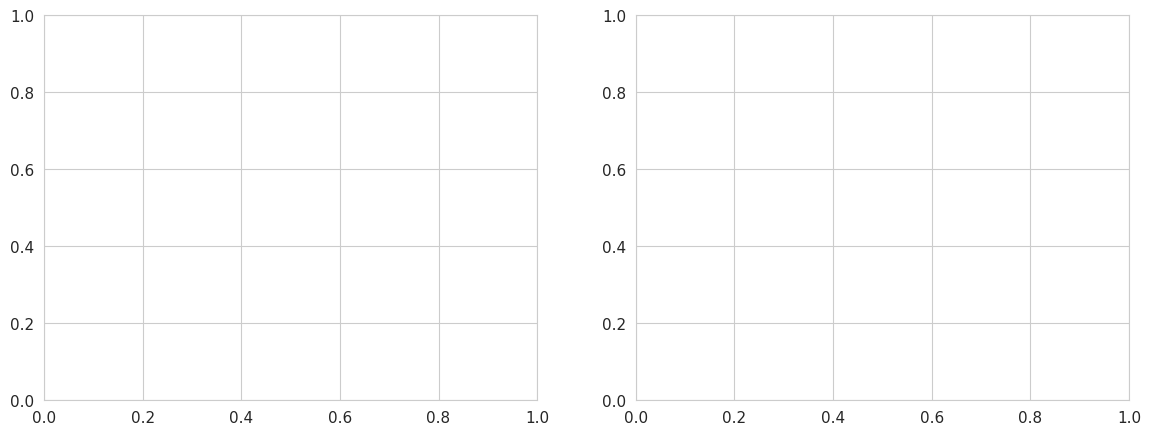

In [49]:
custo_stats = df_filtrado['valor_procedimento'].describe()
print(f"   • Total gasto: R$ {df_filtrado['valor_procedimento'].sum():,.2f}")
print(f"   • Custo médio: R$ {custo_stats['mean']:.2f}")
print(f"   • Mediana: R$ {custo_stats['50%']:.2f}")
print(f"   • Máximo: R$ {custo_stats['max']:.2f}")
print(f"   • Mínimo: R$ {custo_stats['min']:.2f}")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [50]:
# Histograma
ax1 = axes[0]
ax1.hist(df_filtrado['valor_procedimento'], bins=50, color='skyblue', edgecolor='black')
ax1.set_xlabel('Valor do Procedimento (R$)')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição de Custos')
ax1.axvline(custo_stats['mean'], color='red', linestyle='--', label=f'Média: R$ {custo_stats["mean"]:.2f}')
ax1.axvline(custo_stats['50%'], color='green', linestyle='--', label=f'Mediana: R$ {custo_stats["50%"]:.2f}')
ax1.legend()
ax1.set_xlim(0, 500)

(0.0, 500.0)

In [51]:
# Boxplot
ax2 = axes[1]
sns.boxplot(y=df_filtrado['valor_procedimento'], ax=ax2, color='lightcoral')
ax2.set_ylabel('Valor do Procedimento (R$)')
ax2.set_title('Boxplot dos Custos')
ax2.set_ylim(0, 500)

plt.tight_layout()
plt.savefig('../reports/figures/01_distribuicao_custos.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 1200x600 with 0 Axes>


📌 7.3 PERMANÊNCIA HOSPITALAR:
   • Média: 7.28 dias
   • Mediana: 4 dias
   • Máximo: 2845 dias
   • Mínimo: 0 dias


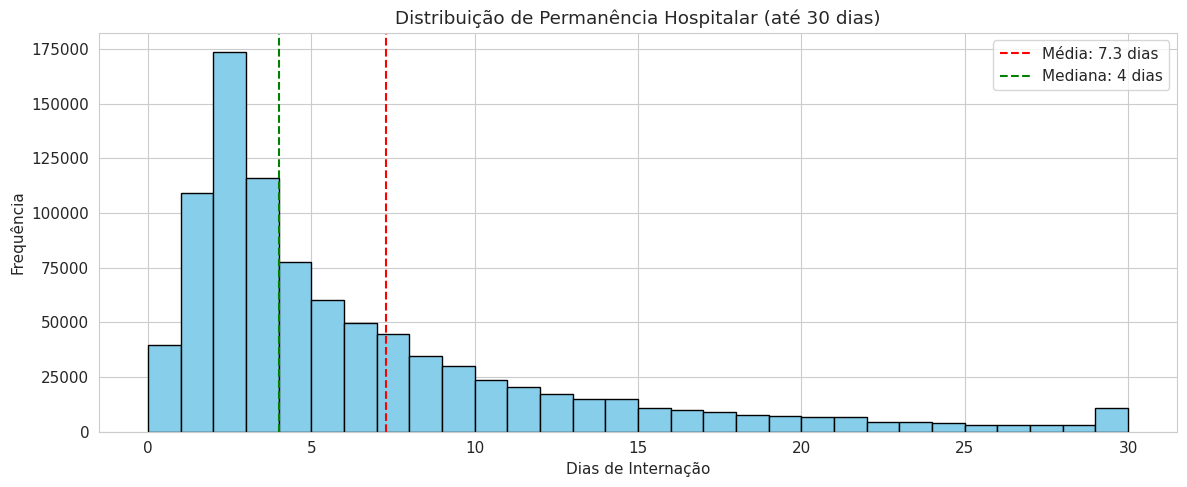

In [52]:
# ==========================================
# 7.3 PERMANÊNCIA HOSPITALAR
# ==========================================

print("\n📌 7.3 PERMANÊNCIA HOSPITALAR:")

permanencia_stats = df_filtrado['dias_internacao'].describe()
print(f"   • Média: {permanencia_stats['mean']:.2f} dias")
print(f"   • Mediana: {permanencia_stats['50%']:.0f} dias")
print(f"   • Máximo: {permanencia_stats['max']:.0f} dias")
print(f"   • Mínimo: {permanencia_stats['min']:.0f} dias")

# Gráfico de permanência
plt.figure(figsize=(12, 5))
plt.hist(df_filtrado[df_filtrado['dias_internacao'] <= 30]['dias_internacao'], 
         bins=30, color='skyblue', edgecolor='black')
plt.axvline(permanencia_stats['mean'], color='red', linestyle='--', 
            label=f'Média: {permanencia_stats["mean"]:.1f} dias')
plt.axvline(permanencia_stats['50%'], color='green', linestyle='--', 
            label=f'Mediana: {permanencia_stats["50%"]:.0f} dias')
plt.xlabel('Dias de Internação')
plt.ylabel('Frequência')
plt.title('Distribuição de Permanência Hospitalar (até 30 dias)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/01_permanencia.png', dpi=150, bbox_inches='tight')
plt.show()


📌 7.4 DESLOCAMENTO DE PACIENTES:
   • Total de pacientes: 949,494
   • Pacientes que viajaram: 643,541
   • Taxa de deslocamento: 67.78%


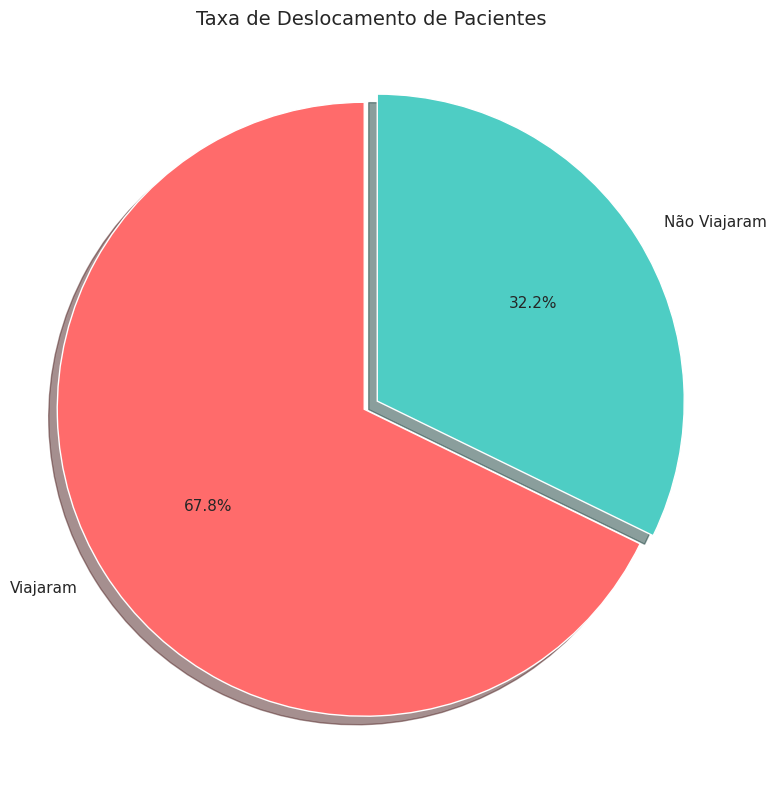

In [53]:
print("\n📌 7.4 DESLOCAMENTO DE PACIENTES:")

total = len(df_filtrado)
viajaram = df_filtrado['paciente_viajou'].sum()
taxa = (viajaram / total) * 100

print(f"   • Total de pacientes: {total:,}")
print(f"   • Pacientes que viajaram: {viajaram:,}")
print(f"   • Taxa de deslocamento: {taxa:.2f}%")

# Gráfico de pizza
plt.figure(figsize=(8, 8))
labels = ['Viajaram', 'Não Viajaram']
sizes = [viajaram, total - viajaram]
colors = ['#ff6b6b', '#4ecdc4']
explode = (0.05, 0)

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode, startangle=90, shadow=True)
plt.title('Taxa de Deslocamento de Pacientes', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.savefig('../reports/figures/01_deslocamento.png', dpi=150, bbox_inches='tight')
plt.show()


In [54]:
# ==========================================
# 7.5 TOP HOSPITAIS
# ==========================================

print("\n📌 7.5 TOP 10 HOSPITAIS POR INTERNAÇÕES:")

top_hospitais = df_filtrado['id_hospital'].value_counts().head(10)
print("   Hospital | Internações")
print("   " + "-"*30)
for i, (hospital, qtd) in enumerate(top_hospitais.items(), 1):
    print(f"   {i:2d}. {hospital} | {qtd:6,}")


📌 7.5 TOP 10 HOSPITAIS POR INTERNAÇÕES:
   Hospital | Internações
   ------------------------------
    1. 0015245 | 64,061
    2. 0013846 | 42,357
    3. 0013633 | 41,529
    4. 2781859 | 40,136
    5. 0015407 | 34,222
    6. 6542638 | 33,396
    7. 2384299 | 31,606
    8. 2738368 | 31,429
    9. 5061989 | 22,189
   10. 0015334 | 19,041



📌 7.6 INTERNAÇÕES POR DIA DA SEMANA:
   Dia da Semana | Internações
   -----------------------------------
   Monday       | 158,225
   Tuesday      | 153,109
   Wednesday    | 148,345
   Thursday     | 148,798
   Friday       | 137,656
   Saturday     | 104,483
   Sunday       | 98,878


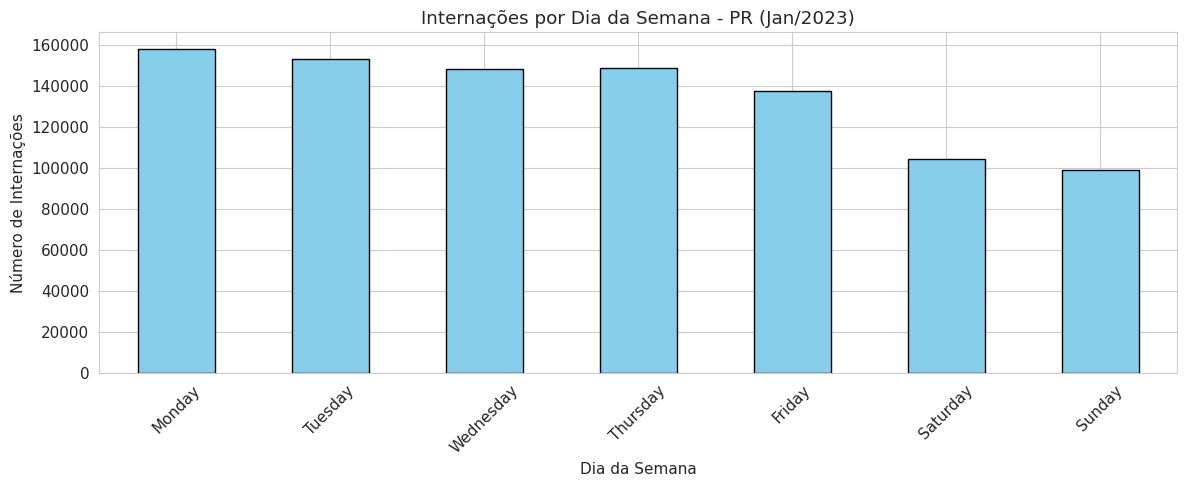

In [55]:
# ==========================================
# 7.6 ANÁLISE TEMPORAL (DIA DA SEMANA)
# ==========================================

print("\n📌 7.6 INTERNAÇÕES POR DIA DA SEMANA:")

ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_semana = df_filtrado['dia_semana'].value_counts().reindex(ordem_dias)

print("   Dia da Semana | Internações")
print("   " + "-"*35)
for dia, qtd in dias_semana.items():
    print(f"   {dia:12} | {qtd:6,}")

# Gráfico
plt.figure(figsize=(12, 5))
dias_semana.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Internações')
plt.title('Internações por Dia da Semana - PR (Jan/2023)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/01_internacoes_por_dia.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# ==========================================
# 7.7 RESUMO DOS INSIGHTS
# ==========================================

print("\n" + "="*60)
print("📋 RESUMO DOS INSIGHTS - MEDDATA")
print("="*60)

insights = [
    ("Top Diagnósticos", "Partos e doenças cardiovasculares são as principais causas"),
    ("Custo Médio", f"R$ {custo_stats['mean']:.2f} por internação"),
    ("Permanência", f"{permanencia_stats['mean']:.1f} dias em média"),
    ("Deslocamento", f"{taxa:.1f}% dos pacientes saem do município"),
    ("Período", "Dias úteis concentram a maioria das internações"),
]
print(f"{insights}")


📋 RESUMO DOS INSIGHTS - MEDDATA
[('Top Diagnósticos', 'Partos e doenças cardiovasculares são as principais causas'), ('Custo Médio', 'R$ 144.40 por internação'), ('Permanência', '7.3 dias em média'), ('Deslocamento', '67.8% dos pacientes saem do município'), ('Período', 'Dias úteis concentram a maioria das internações')]


In [57]:
# ==========================================
# SEÇÃO 8: FINALIZAÇÃO E DOCUMENTAÇÃO
# ==========================================

print("\n" + "="*60)
print("📋 FINALIZAÇÃO DO NOTEBOOK")
print("="*60)

# ==========================================
# 8.1 SALVAR DADOS LIMPOS
# ==========================================

print("\n📌 8.1 SALVANDO DADOS LIMPOS:")

caminho_parquet = '../data/processed/sih_clean_PR_2023_01.parquet'
df_filtrado.to_parquet(caminho_parquet)

# Salvar também em CSV (para visualização rápida)
caminho_csv = '../data/processed/sih_clean_PR_2023_01.csv'
df_filtrado.to_csv(caminho_csv, index=False)

print(f"   ✅ Dados salvos em Parquet: {caminho_parquet}")
print(f"   ✅ Dados salvos em CSV: {caminho_csv}")
print(f"   • Registros: {len(df_filtrado):,}")
print(f"   • Colunas: {len(df_filtrado.columns)}")
print(f"   • Colunas: {df_filtrado.columns.tolist()}")

# ==========================================
# 8.2 RESUMO DO DATASET
# ==========================================

print("\n📌 8.2 RESUMO DO DATASET:")

resumo = {
    'Total de Registros': f"{len(df_filtrado):,}",
    'Total de Colunas': len(df_filtrado.columns),
    'Período': 'Janeiro/2023',
    'Estado': 'Paraná (PR)',
    'Hospitais Únicos': df_filtrado['id_hospital'].nunique(),
    'Municípios Únicos': df_filtrado['codigo_municipio'].nunique(),
    'Diagnósticos Únicos': df_filtrado['codigo_diagnostico'].nunique(),
    'Total de Custos': f"R$ {df_filtrado['valor_procedimento'].sum():,.2f}",
    'Custo Médio': f"R$ {df_filtrado['valor_procedimento'].mean():.2f}",
    'Permanência Média': f"{df_filtrado['dias_internacao'].mean():.2f} dias",
    'Taxa de Deslocamento': f"{(df_filtrado['paciente_viajou'].sum() / len(df_filtrado) * 100):.2f}%",
}

for chave, valor in resumo.items():
    print(f"   • {chave}: {valor}")

# ==========================================
# 8.3 DECISÕES DE TRANSFORMAÇÃO (para o script)
# ==========================================

print("\n📌 8.3 DECISÕES PARA O SCRIPT DE TRANSFORMAÇÃO:")

decisoes = [
    ("1. Colunas mantidas", "SP_GESTOR, SP_CNES, SP_CIDPRI, SP_DTINTER, SP_DTSAIDA, SP_VALATO, SP_M_PAC, SP_AA, SP_MM"),
    ("2. Colunas removidas", "27 colunas operacionais/administrativas (SP_NAIH, SP_UF, etc.)"),
    ("3. Conversão de tipos", "Datas → datetime, SP_VALATO → float, SP_AA/SP_MM → int"),
    ("4. Padronização", "ID_HOSPITAL → zfill(7) para integração com CNES"),
    ("5. Novas colunas", "dias_internacao, paciente_viajou, dia_semana, mes_ano, tipo_dia"),
    ("6. Duplicatas", "Removidas 72.929 duplicatas exatas (7,13%)"),
    ("7. Valores nulos", "Nenhum valor nulo encontrado (dados completos)"),
]

print("\n   📋 DECISÕES DE TRANSFORMAÇÃO:")
for decisao in decisoes:
    print(f"   {decisao[0]}: {decisao[1]}")

# ==========================================
# 8.4 PRÓXIMOS PASSOS
# ==========================================

print("\n📌 8.4 PRÓXIMOS PASSOS:")

proximos_passos = [
    "1. Criar notebook de EDA do CNES (02_eda_cnes.ipynb)",
    "2. Criar notebook de EDA do IBGE (03_eda_ibge.ipynb)",
    "3. Criar notebook de integração dos 3 datasets (04_integracao.ipynb)",
    "4. Criar script de transformação (transformacao.py)",
    "5. Criar script de indicadores (indicadores.py)",
    "6. Subir dados para OCI (Autonomous Database)",
]

for passo in proximos_passos:
    print(f"   • {passo}")

# ==========================================
# 8.5 CHECKLIST DO NOTEBOOK
# ==========================================

print("\n📌 8.5 CHECKLIST DO NOTEBOOK:")

checklist = [
    ("Configuração inicial", "✅"),
    ("Carregamento dos dados", "✅"),
    ("Análise de estrutura e tipos", "✅"),
    ("Análise de qualidade (nulos, duplicatas)", "✅"),
    ("Seleção de colunas essenciais", "✅"),
    ("Renomeação e conversão de tipos", "✅"),
    ("Criação de novas colunas", "✅"),
    ("Análise exploratória (insights)", "✅"),
    ("Salvamento dos dados limpos", "✅"),
    ("Documentação e decisões", "✅"),
]

print("\n   📋 STATUS DO NOTEBOOK:")
for item, status in checklist:
    print(f"   • {item}: {status}")

print("\n" + "="*60)
print("🎉 NOTEBOOK CONCLUÍDO COM SUCESSO!")
print("="*60)


📋 FINALIZAÇÃO DO NOTEBOOK

📌 8.1 SALVANDO DADOS LIMPOS:


   ✅ Dados salvos em Parquet: ../data/processed/sih_clean_PR_2023_01.parquet
   ✅ Dados salvos em CSV: ../data/processed/sih_clean_PR_2023_01.csv
   • Registros: 949,494
   • Colunas: 14
   • Colunas: ['codigo_municipio', 'id_hospital', 'codigo_diagnostico', 'data_internacao', 'data_saida', 'valor_procedimento', 'codigo_municipio_paciente', 'ano_competencia', 'mes_competencia', 'dias_internacao', 'paciente_viajou', 'dia_semana', 'mes_ano', 'tipo_dia']

📌 8.2 RESUMO DO DATASET:
   • Total de Registros: 949,494
   • Total de Colunas: 14
   • Período: Janeiro/2023
   • Estado: Paraná (PR)
   • Hospitais Únicos: 284
   • Municípios Únicos: 31
   • Diagnósticos Únicos: 3588
   • Total de Custos: R$ 137,110,227.26
   • Custo Médio: R$ 144.40
   • Permanência Média: 7.28 dias
   • Taxa de Deslocamento: 67.78%

📌 8.3 DECISÕES PARA O SCRIPT DE TRANSFORMAÇÃO:

   📋 DECISÕES DE TRANSFORMAÇÃO:
   1. Colunas mantidas: SP_GESTOR, SP_CNES, SP_CIDPRI, SP_DTINTER, SP_DTSAIDA, SP_VALATO, SP_M_PAC, SP_AA